In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import catboost as cgb
except:
    !uv pip install catboost
    import catboost as cgb

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


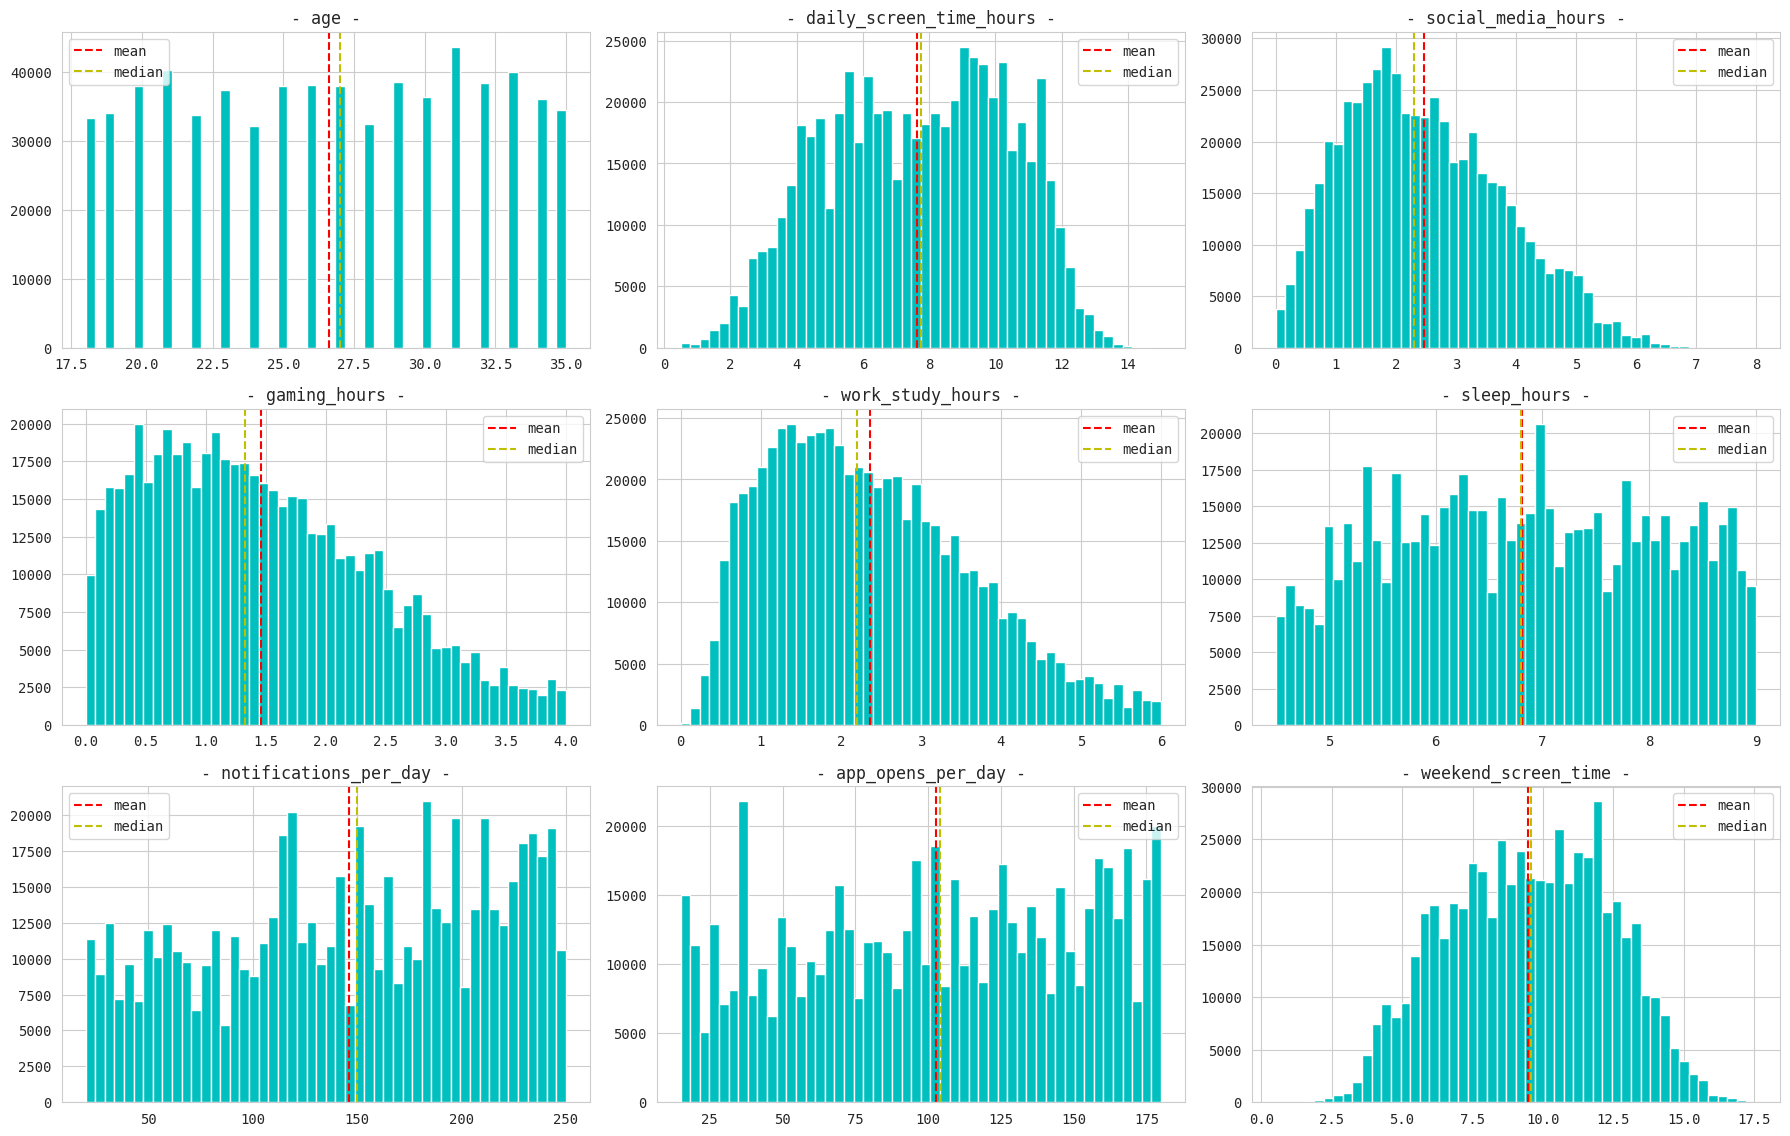

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Test
age,18,18
daily_screen_time_hours,1389,1349
social_media_hours,721,703
gaming_hours,401,401
work_study_hours,600,601
sleep_hours,451,451
notifications_per_day,231,231
app_opens_per_day,166,166
weekend_screen_time,1437,1404
gender,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end='')
# for col in NUMS: # 'Position_Change'
#     freq = pd.concat([train[col], test[col]]).value_counts(normalize=True) # orig[col], 
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test]: # , orig
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")
# train[FREQ_COLS]

In [17]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [18]:
# ## -- Arithmetic interactions --
# for df in [train, test]: # , orig
#     # df["_weeknd_X_daily"] = (
#     #                                     df["weekend_screen_time"] + \
#     #                                     df["daily_screen_time_hours"]).astype('float32')
#     # df["_gaming_X_daily_X_social"] = (
#     #                                     df["gaming_hours"] + \
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"]).astype('float32')
#     df["_daily_X_social_X_weekend"] = (
#                                         df["daily_screen_time_hours"] + \
#                                         df["social_media_hours"] + \
#                                         df["weekend_screen_time"]).astype("float32")
#     # df["_daily_X_social_X_work_/_sleep"] = ((
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"] + \
#     #                                     df["work_study_hours"]) / (df["sleep_hours"]+1e-8)).astype('float32')

# ARITHMETIC_COLS = [
#     # "_weeknd_X_daily",
#     # "_gaming_X_daily_X_social",
#     "_daily_X_social_X_weekend",
#     # "_daily_X_social_X_work_/_sleep",
#     # '_LapTime (s)_*_Cum_Deg_abs',
#     # '_LapTime (s)_/_Cum_Deg_abs',
# ]

# print(f"Total Arithmetic interactions: {len(ARITHMETIC_COLS)}")

# train[ARITHMETIC_COLS]

In [19]:
# ## -- Cyclic encoding --
# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [20]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    # num_to_cat = []
    # for col in num_features_:
    #     cat_name = f"{col}_cat"
    #     df[cat_name] = df[col].fillna('NaN').astype(str)
    #     num_to_cat.append(cat_name)

    # for c in num_features_:
    #     for i in [0,1]:
    #         df[f"{c}_round{i}"] = df[c].round(i)

    social = df['social_media_hours']
    gaming = df['gaming_hours']
    work = df['work_study_hours']
    daily = df['daily_screen_time_hours']
    sleep = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')
    
    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('int8')
        
    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    return df

train = apply_feature_engineering(train, NUMS, CATS)
test  = apply_feature_engineering(test, NUMS, CATS)
orig  = apply_feature_engineering(orig, NUMS, CATS)

NEW_CATS = ["ci_case", "ci_n_missing", "missing_count"]
train[NEW_CATS] = train[NEW_CATS].fillna(-1)
test[NEW_CATS]  = test[NEW_CATS].fillna(-1)
# orig[NEW_CATS]  = orig[NEW_CATS].fillna(-1)

CATS.extend(NEW_CATS)

train

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0,0.0,0
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,5
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,0.0,0.0,2


In [21]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [22]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [23]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# train

In [24]:
train["orig_preds"] = np.load(
    "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
)

test["orig_preds"]  = np.load(
    "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
)

In [25]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize -- 
#     combined  = pd.concat([train[n], test[n] , orig[n]]) #
#     cat_v = combined.factorize()[0]
#     # cat_v = pd.Series(cat_v).astype(str)
#     train[n] = cat_v[:len(train)].astype('int32')
#     test[n]  = cat_v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = cat_v[len(train)+len(test):].astype('int32')

# del combined, cat_v
# print(f"Nums to Cats: {len(CATS_2)}")

# CATS_2

In [26]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in NUMS:
#     n = f"cat_{c}"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
## ------------------------------------------------------------
## -- Factorize all CATS data --
for c in CATS:
    combined[c] = combined[c].factorize()[0]
    # combined[c] = combined[c].astype('category')
    
train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Total Features: 30
Label encoding complete!


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,orig_preds,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,0,0,0,0.197407,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,1,0,1,0.089317,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,2,1,2,0.005602,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,2,2,0,0.475512,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,2,2,1,0.999303,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,2,2,0,0.999530,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,2,2,3,0.003372,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,2,0,0,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,5,0.184947,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,2,-1,-1,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,2,2,1,0.998378,1.0


# ML TRAINING

In [27]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols,
               use_orig=False, early_stop=100, print_every=200):
    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()

    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits}", end=" | ")

        ## -- Split data for the current fold
        X_train, X_valid = X.loc[train_idx], X.loc[val_idx]
        y_train, y_valid = y.loc[train_idx], y.loc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
                orig,
                X_train,
                X_valid,
                X_test,
                features=BASE,
                target=TARGET,
                aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
                fill_nan=True,
            )

        # ## -- TE Opt1. -> Using CUSTOM -- 
        # te_enc  = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        all_categorical = cat_cols.copy()
        
        combined = pd.concat([X_train, X_valid, X_test])
        for c in all_categorical:
            combined[c] = combined[c].astype(str)
        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=10_000,
            eval_set=dval,
            early_stopping_rounds=early_stop,
            verbose=print_every,
        )

        feat_importances.append(model.get_feature_importance(prettified=True))

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1].ravel()
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1].ravel() / kfold.n_splits

        # Calculate and print fold score
        fold_score = roc_auc_score(y_valid.to_numpy(), oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        # Clean up memory
        del dtrain, dval, dtest
        # gc.collect()

    # # Average test predictions
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {score:.6f}")

    ## -- Out-of-fold AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time() - t0) / 60):.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [28]:
VER = f"cat_fe{30}_"
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS #+ CATS_2

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,orig_preds,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,0,0,0,0.197407,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,1,0,1,0.089317,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,2,1,2,0.005602,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,2,2,0,0.475512,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,2,2,1,0.999303,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,2,2,0,0.999530,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,2,2,3,0.003372,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,2,0,0,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,5,0.184947,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,2,-1,-1,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,2,2,1,0.998378,1.0


In [29]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# COMPILER = []

# OUT_LOOP = [0.5, 1.0]
# INN_LOOP = [4.0]
# p_name   = ['BT', 'L1']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': outer,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.05,
#             # 'depth': 6,
#             # 'l2_leaf_reg': REGULATE,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=CATS+DIGITS+['cat_tenure'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

In [30]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# # pd.Series(all_model_scores).plot(marker='o')
# sns.lineplot(all_model_scores, marker='o')
# plt.title('CATBoost Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score-5e-8, score, ha='right', va='baseline')

# plt.tick_params('x', rotation=45, reset=True)
# plt.show()

In [31]:
LR = 0.03
# L2_REG = 2.5
EARLY_STOP   = 100
PRINT_STEPS  = 1000
USE_ORIGINAL = False

In [32]:
## ========================== BAYESIAN 
bayes_params = {
    'boosting_type': 'Plain',
    'grow_policy': 'SymmetricTree',
    'bootstrap_type': 'Bayesian',
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'bagging_temperature': 0.2,
    # 'random_strength': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bayes_params,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_fe30_bayes =====

##### FOLD 1/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9087217	best: 0.9087217 (0)	total: 149ms	remaining: 24m 53s
1000:	test: 0.9528633	best: 0.9528633 (1000)	total: 36.3s	remaining: 5m 26s
2000:	test: 0.9571709	best: 0.9571709 (2000)	total: 1m 12s	remaining: 4m 51s
3000:	test: 0.9586582	best: 0.9586582 (3000)	total: 1m 50s	remaining: 4m 16s
4000:	test: 0.9593691	best: 0.9593694 (3997)	total: 2m 27s	remaining: 3m 40s
5000:	test: 0.9597406	best: 0.9597406 (5000)	total: 3m 4s	remaining: 3m 4s
6000:	test: 0.9599591	best: 0.9599591 (6000)	total: 3m 42s	remaining: 2m 28s
7000:	test: 0.9600961	best: 0.9600962 (6999)	total: 4m 20s	remaining: 1m 51s
8000:	test: 0.9601775	best: 0.9601786 (7987)	total: 4m 58s	remaining: 1m 14s
9000:	test: 0.9602292	best: 0.9602292 (9000)	total: 5m 36s	remaining: 37.4s
bestTest = 0.9602696896
bestIteration = 9723
Shrink model to first 9724 iterations.
 • Fold 1 AUC: 0.960270

##### FOLD 2/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9091925	best: 0.9091925 (0)	total: 52ms	remaining: 8m 39s
1000:	test: 0.9538230	best: 0.9538230 (1000)	total: 36.8s	remaining: 5m 31s
2000:	test: 0.9579454	best: 0.9579454 (2000)	total: 1m 13s	remaining: 4m 54s
3000:	test: 0.9594132	best: 0.9594132 (3000)	total: 1m 50s	remaining: 4m 18s
4000:	test: 0.9600658	best: 0.9600658 (4000)	total: 2m 28s	remaining: 3m 42s
5000:	test: 0.9604522	best: 0.9604522 (5000)	total: 3m 5s	remaining: 3m 5s
6000:	test: 0.9606571	best: 0.9606571 (6000)	total: 3m 43s	remaining: 2m 29s
7000:	test: 0.9607952	best: 0.9607968 (6994)	total: 4m 21s	remaining: 1m 52s
8000:	test: 0.9608922	best: 0.9608923 (7999)	total: 4m 59s	remaining: 1m 14s
9000:	test: 0.9609653	best: 0.9609658 (8999)	total: 5m 37s	remaining: 37.5s
bestTest = 0.960991919
bestIteration = 9438
Shrink model to first 9439 iterations.
 • Fold 2 AUC: 0.960992

##### FOLD 3/5 | shape: (553095, 30)


...

0:	test: 0.9101037	best: 0.9101037 (0)	total: 53.8ms	remaining: 8m 57s
1000:	test: 0.9540716	best: 0.9540716 (1000)	total: 36.8s	remaining: 5m 31s
2000:	test: 0.9581361	best: 0.9581361 (2000)	total: 1m 13s	remaining: 4m 53s
3000:	test: 0.9596832	best: 0.9596832 (3000)	total: 1m 50s	remaining: 4m 17s
4000:	test: 0.9603519	best: 0.9603519 (4000)	total: 2m 27s	remaining: 3m 41s
5000:	test: 0.9606851	best: 0.9606851 (5000)	total: 3m 5s	remaining: 3m 4s
6000:	test: 0.9608954	best: 0.9608954 (5998)	total: 3m 42s	remaining: 2m 28s
7000:	test: 0.9610240	best: 0.9610240 (7000)	total: 4m 20s	remaining: 1m 51s
8000:	test: 0.9610931	best: 0.9610948 (7948)	total: 4m 58s	remaining: 1m 14s
bestTest = 0.9611250758
bestIteration = 8580
Shrink model to first 8581 iterations.
 • Fold 3 AUC: 0.961125

##### FOLD 4/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9098749	best: 0.9098749 (0)	total: 52.3ms	remaining: 8m 43s
1000:	test: 0.9550424	best: 0.9550424 (1000)	total: 37s	remaining: 5m 32s
2000:	test: 0.9590485	best: 0.9590485 (2000)	total: 1m 13s	remaining: 4m 54s
3000:	test: 0.9605303	best: 0.9605303 (3000)	total: 1m 50s	remaining: 4m 18s
4000:	test: 0.9612231	best: 0.9612231 (4000)	total: 2m 28s	remaining: 3m 42s
5000:	test: 0.9615687	best: 0.9615687 (5000)	total: 3m 5s	remaining: 3m 5s
6000:	test: 0.9617951	best: 0.9617960 (5989)	total: 3m 43s	remaining: 2m 28s
bestTest = 0.9618992805
bestIteration = 6817
Shrink model to first 6818 iterations.
 • Fold 4 AUC: 0.961899

##### FOLD 5/5 | shape: (553096, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9099572	best: 0.9099572 (0)	total: 53.1ms	remaining: 8m 51s
1000:	test: 0.9541253	best: 0.9541253 (1000)	total: 37.1s	remaining: 5m 33s
2000:	test: 0.9579523	best: 0.9579523 (2000)	total: 1m 14s	remaining: 4m 56s
3000:	test: 0.9594498	best: 0.9594498 (3000)	total: 1m 51s	remaining: 4m 20s
4000:	test: 0.9600567	best: 0.9600570 (3999)	total: 2m 28s	remaining: 3m 43s
5000:	test: 0.9603803	best: 0.9603813 (4992)	total: 3m 6s	remaining: 3m 6s
6000:	test: 0.9605953	best: 0.9605953 (6000)	total: 3m 44s	remaining: 2m 29s
7000:	test: 0.9607044	best: 0.9607044 (7000)	total: 4m 22s	remaining: 1m 52s
8000:	test: 0.9607743	best: 0.9607748 (7997)	total: 5m	remaining: 1m 15s
9000:	test: 0.9608166	best: 0.9608172 (8997)	total: 5m 38s	remaining: 37.6s
bestTest = 0.9608460367
bestIteration = 9479
Shrink model to first 9480 iterations.
 • Fold 5 AUC: 0.960846

5-FOLD CV: cat_fe30_bayes
 • Fold 1 AUC: 0.960270
 • Fold 2 AUC: 0.960992
 • Fold 3 AUC: 0.961125
 • Fold 4 AUC: 0.961899
 • Fold 5 AUC

In [33]:
# ==================================================
# 5-FOLD CV: cat_TE(84)_bayes | (553095, 84)
# ==================================================
#  • Fold 1 AUC: 0.966638
#  • Fold 2 AUC: 0.967381
#  • Fold 3 AUC: 0.967625
#  • Fold 4 AUC: 0.967941
#  • Fold 5 AUC: 0.967004
# -------------------------------------------------|
# Overall AUC: 0.967317
# Average AUC: 0.967318 ± 0.000458
# -------------------------------------------------|
# 17.24 mins

# ==================================================
# 5-FOLD CV: cat_boostTE(84)_bayes | (553095, 84)
# ==================================================
#  • Fold 1 AUC: 0.966750
#  • Fold 2 AUC: 0.967561
#  • Fold 3 AUC: 0.967626
#  • Fold 4 AUC: 0.968173
#  • Fold 5 AUC: 0.967134
# -------------------------------------------------|
# Overall AUC: 0.967447
# Average AUC: 0.967449 ± 0.000481
# -------------------------------------------------|
# 42.33 mins

In [34]:
# ## =========================== MVS -- OOM issues
# mvs_params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     # 'learning_rate': LR,
#     # ---------------------------------
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     # 'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     # 'depth': 6,
#     # 'l2_leaf_reg': L2_REG,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'thread_count': -1,
#     'allow_writing_files': False,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = VER+"cat_mvs"

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=mvs_params,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     use_orig=USE_ORIGINAL,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
# )

In [35]:
## =========================== BERNOULLI
bern_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Plain",
    'grow_policy': "Depthwise",
    'bootstrap_type': "Bernoulli",
    # ---------------------------------
    # 'subsample': 0.8, # auto 0.66
    # 'colsample_bylevel': 0.7,
    'min_data_in_leaf': 40,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "bern"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bern_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS
)


===== Starting CV: cat_fe30_bern =====

##### FOLD 1/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9232897	best: 0.9232897 (0)	total: 119ms	remaining: 19m 47s
1000:	test: 0.9581167	best: 0.9581167 (1000)	total: 23.8s	remaining: 3m 33s
2000:	test: 0.9596441	best: 0.9596446 (1999)	total: 46.2s	remaining: 3m 4s
3000:	test: 0.9600851	best: 0.9600856 (2999)	total: 1m 9s	remaining: 2m 41s
4000:	test: 0.9602629	best: 0.9602647 (3988)	total: 1m 32s	remaining: 2m 18s
bestTest = 0.9602814317
bestIteration = 4169
Shrink model to first 4170 iterations.
 • Fold 1 AUC: 0.960281

##### FOLD 2/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9234841	best: 0.9234841 (0)	total: 39.6ms	remaining: 6m 35s
1000:	test: 0.9586857	best: 0.9586857 (1000)	total: 23.2s	remaining: 3m 28s
2000:	test: 0.9602310	best: 0.9602310 (2000)	total: 45.6s	remaining: 3m 2s
3000:	test: 0.9606344	best: 0.9606344 (3000)	total: 1m 8s	remaining: 2m 39s
4000:	test: 0.9608119	best: 0.9608120 (3999)	total: 1m 30s	remaining: 2m 15s
bestTest = 0.9608692527
bestIteration = 4476
Shrink model to first 4477 iterations.
 • Fold 2 AUC: 0.960869

##### FOLD 3/5 | shape: (553095, 30)


...

0:	test: 0.9247392	best: 0.9247392 (0)	total: 36.6ms	remaining: 6m 6s
1000:	test: 0.9591795	best: 0.9591795 (1000)	total: 22.8s	remaining: 3m 24s
2000:	test: 0.9605108	best: 0.9605108 (2000)	total: 45.2s	remaining: 3m
3000:	test: 0.9608356	best: 0.9608365 (2991)	total: 1m 7s	remaining: 2m 37s
bestTest = 0.9609313011
bestIteration = 3587
Shrink model to first 3588 iterations.
 • Fold 3 AUC: 0.960931

##### FOLD 4/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9243931	best: 0.9243931 (0)	total: 38.4ms	remaining: 6m 23s
1000:	test: 0.9600750	best: 0.9600750 (1000)	total: 22.9s	remaining: 3m 25s
2000:	test: 0.9614044	best: 0.9614044 (2000)	total: 45.3s	remaining: 3m 1s
3000:	test: 0.9617618	best: 0.9617618 (3000)	total: 1m 7s	remaining: 2m 38s
bestTest = 0.9618544579
bestIteration = 3506
Shrink model to first 3507 iterations.
 • Fold 4 AUC: 0.961855

##### FOLD 5/5 | shape: (553096, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9243454	best: 0.9243454 (0)	total: 40.5ms	remaining: 6m 44s
1000:	test: 0.9588888	best: 0.9588888 (1000)	total: 22.8s	remaining: 3m 24s
2000:	test: 0.9603537	best: 0.9603537 (2000)	total: 45.1s	remaining: 3m
3000:	test: 0.9606996	best: 0.9606996 (2998)	total: 1m 7s	remaining: 2m 37s
bestTest = 0.9608017206
bestIteration = 3563
Shrink model to first 3564 iterations.
 • Fold 5 AUC: 0.960802

5-FOLD CV: cat_fe30_bern
 • Fold 1 AUC: 0.960281
 • Fold 2 AUC: 0.960869
 • Fold 3 AUC: 0.960931
 • Fold 4 AUC: 0.961855
 • Fold 5 AUC: 0.960802
-------------------------------------------------|
Overall AUC: 0.960941
Average AUC: 0.960948 ± 0.000509
-------------------------------------------------|
9.25 mins



In [36]:
# ==================================================
# 5-FOLD CV: cat_TE_bern
# ==================================================
#  • Fold 1 AUC: 0.966163
#  • Fold 2 AUC: 0.966866
#  • Fold 3 AUC: 0.967248
#  • Fold 4 AUC: 0.967543
#  • Fold 5 AUC: 0.966586
# -------------------------------------------------|
# Overall AUC: 0.96688
# Average AUC: 0.966881 ± 0.000485
# -------------------------------------------------|
# 8.91 mins

In [37]:
## =========================== LOSSGUIDE

loss_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 6,
    # ---------------------------------
    'boosting_type': 'Plain',
    'grow_policy': 'Lossguide',
    # ---------------------------------
    # 'max_leaves': 32,
    'min_data_in_leaf': 2,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "loss"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=loss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_fe30_loss =====

##### FOLD 1/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9200064	best: 0.9200064 (0)	total: 46.4ms	remaining: 7m 44s
1000:	test: 0.9583060	best: 0.9583060 (1000)	total: 32.8s	remaining: 4m 55s
2000:	test: 0.9597448	best: 0.9597448 (2000)	total: 1m 5s	remaining: 4m 21s
3000:	test: 0.9601998	best: 0.9601998 (3000)	total: 1m 38s	remaining: 3m 49s
4000:	test: 0.9603760	best: 0.9603765 (3986)	total: 2m 8s	remaining: 3m 13s
5000:	test: 0.9604890	best: 0.9604890 (4992)	total: 2m 42s	remaining: 2m 42s
bestTest = 0.9605294466
bestIteration = 5485
Shrink model to first 5486 iterations.
 • Fold 1 AUC: 0.960530

##### FOLD 2/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9193532	best: 0.9193532 (0)	total: 44.6ms	remaining: 7m 25s
1000:	test: 0.9588436	best: 0.9588436 (1000)	total: 32.4s	remaining: 4m 51s
2000:	test: 0.9603426	best: 0.9603426 (1997)	total: 1m 4s	remaining: 4m 18s
3000:	test: 0.9607613	best: 0.9607613 (3000)	total: 1m 38s	remaining: 3m 49s
4000:	test: 0.9609585	best: 0.9609587 (3997)	total: 2m 10s	remaining: 3m 15s
5000:	test: 0.9610705	best: 0.9610705 (5000)	total: 2m 41s	remaining: 2m 41s
6000:	test: 0.9611417	best: 0.9611426 (5977)	total: 3m 12s	remaining: 2m 8s
bestTest = 0.9611642361
bestIteration = 6369
Shrink model to first 6370 iterations.
 • Fold 2 AUC: 0.961164

##### FOLD 3/5 | shape: (553095, 30)


...

0:	test: 0.9214980	best: 0.9214980 (0)	total: 42.8ms	remaining: 7m 8s
1000:	test: 0.9593260	best: 0.9593260 (1000)	total: 32.4s	remaining: 4m 51s
2000:	test: 0.9605725	best: 0.9605725 (2000)	total: 1m 5s	remaining: 4m 21s
3000:	test: 0.9610034	best: 0.9610051 (2991)	total: 1m 35s	remaining: 3m 43s
4000:	test: 0.9611627	best: 0.9611627 (3996)	total: 2m 7s	remaining: 3m 11s
5000:	test: 0.9612727	best: 0.9612743 (4986)	total: 2m 37s	remaining: 2m 37s
bestTest = 0.9612743258
bestIteration = 4986
Shrink model to first 4987 iterations.
 • Fold 3 AUC: 0.961274

##### FOLD 4/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9207121	best: 0.9207121 (0)	total: 42.6ms	remaining: 7m 5s
1000:	test: 0.9603201	best: 0.9603201 (1000)	total: 34.5s	remaining: 5m 10s
2000:	test: 0.9616700	best: 0.9616700 (2000)	total: 1m 7s	remaining: 4m 30s
3000:	test: 0.9620879	best: 0.9620879 (3000)	total: 1m 39s	remaining: 3m 52s
4000:	test: 0.9622703	best: 0.9622703 (4000)	total: 2m 9s	remaining: 3m 13s
5000:	test: 0.9623571	best: 0.9623571 (5000)	total: 2m 41s	remaining: 2m 41s
bestTest = 0.962358892
bestIteration = 5019
Shrink model to first 5020 iterations.
 • Fold 4 AUC: 0.962359

##### FOLD 5/5 | shape: (553096, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9216836	best: 0.9216836 (0)	total: 47.2ms	remaining: 7m 51s
1000:	test: 0.9591894	best: 0.9591894 (1000)	total: 31.6s	remaining: 4m 43s
2000:	test: 0.9604007	best: 0.9604007 (2000)	total: 1m 2s	remaining: 4m 8s
3000:	test: 0.9608065	best: 0.9608065 (2999)	total: 1m 34s	remaining: 3m 39s
4000:	test: 0.9609982	best: 0.9609982 (4000)	total: 2m 7s	remaining: 3m 11s
5000:	test: 0.9611080	best: 0.9611092 (4997)	total: 2m 39s	remaining: 2m 39s
bestTest = 0.9611243606
bestIteration = 5221
Shrink model to first 5222 iterations.
 • Fold 5 AUC: 0.961124

5-FOLD CV: cat_fe30_loss
 • Fold 1 AUC: 0.960530
 • Fold 2 AUC: 0.961164
 • Fold 3 AUC: 0.961274
 • Fold 4 AUC: 0.962359
 • Fold 5 AUC: 0.961124
-------------------------------------------------|
Overall AUC: 0.961287
Average AUC: 0.961290 ± 0.000594
-------------------------------------------------|
16.92 mins



In [38]:
# ==================================================
# 5-FOLD CV: cat_TE_loss
# ==================================================
#  • Fold 1 AUC: 0.966239
#  • Fold 2 AUC: 0.967102
#  • Fold 3 AUC: 0.967352
#  • Fold 4 AUC: 0.967591
#  • Fold 5 AUC: 0.966620
# -------------------------------------------------|
# Overall AUC: 0.966981
# Average AUC: 0.966981 ± 0.000491
# -------------------------------------------------|
# 16.69 mins

In [39]:
## =========================== ORDERED 

ord_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Ordered",
    'grow_policy': "SymmetricTree",
    'bootstrap_type': "Bayesian",
    # ---------------------------------
    'bagging_temperature': 0.2,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "ord_bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=ord_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_fe30_ord_bayes =====

##### FOLD 1/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9083022	best: 0.9083022 (0)	total: 151ms	remaining: 25m 12s
1000:	test: 0.9520936	best: 0.9520936 (1000)	total: 1m 24s	remaining: 12m 36s
2000:	test: 0.9558911	best: 0.9558911 (1999)	total: 2m 48s	remaining: 11m 13s
3000:	test: 0.9574307	best: 0.9574307 (2999)	total: 4m 11s	remaining: 9m 45s
4000:	test: 0.9581299	best: 0.9581299 (4000)	total: 5m 37s	remaining: 8m 25s
5000:	test: 0.9585438	best: 0.9585438 (5000)	total: 7m	remaining: 7m
6000:	test: 0.9588508	best: 0.9588508 (6000)	total: 8m 25s	remaining: 5m 36s
7000:	test: 0.9590945	best: 0.9590945 (6928)	total: 9m 48s	remaining: 4m 12s
bestTest = 0.9591071606
bestIteration = 7490
Shrink model to first 7491 iterations.
 • Fold 1 AUC: 0.959107

##### FOLD 2/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9091925	best: 0.9091925 (0)	total: 147ms	remaining: 24m 33s
1000:	test: 0.9537026	best: 0.9537026 (1000)	total: 1m 23s	remaining: 12m 33s
2000:	test: 0.9573426	best: 0.9573426 (2000)	total: 2m 46s	remaining: 11m 3s
3000:	test: 0.9582411	best: 0.9582411 (2996)	total: 3m 56s	remaining: 9m 11s
bestTest = 0.9583958983
bestIteration = 3587
Shrink model to first 3588 iterations.
 • Fold 2 AUC: 0.958396

##### FOLD 3/5 | shape: (553095, 30)


...

0:	test: 0.9101037	best: 0.9101037 (0)	total: 145ms	remaining: 24m 7s
1000:	test: 0.9538980	best: 0.9538980 (1000)	total: 1m 23s	remaining: 12m 30s
2000:	test: 0.9570965	best: 0.9570965 (2000)	total: 2m 45s	remaining: 11m 2s
3000:	test: 0.9582325	best: 0.9582325 (3000)	total: 4m 8s	remaining: 9m 39s
4000:	test: 0.9587057	best: 0.9587058 (3993)	total: 5m 33s	remaining: 8m 19s
5000:	test: 0.9593087	best: 0.9593089 (4998)	total: 6m 57s	remaining: 6m 57s
6000:	test: 0.9598069	best: 0.9598070 (5997)	total: 8m 23s	remaining: 5m 35s
7000:	test: 0.9600297	best: 0.9600297 (6996)	total: 9m 46s	remaining: 4m 11s
8000:	test: 0.9601903	best: 0.9601904 (7999)	total: 11m 13s	remaining: 2m 48s
9000:	test: 0.9602951	best: 0.9602954 (8993)	total: 12m 39s	remaining: 1m 24s
9999:	test: 0.9604036	best: 0.9604036 (9999)	total: 14m 5s	remaining: 0us
bestTest = 0.9604036212
bestIteration = 9999
 • Fold 3 AUC: 0.960404

##### FOLD 4/5 | shape: (553095, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9097358	best: 0.9097358 (0)	total: 148ms	remaining: 24m 44s
1000:	test: 0.9548610	best: 0.9548610 (1000)	total: 1m 23s	remaining: 12m 34s
2000:	test: 0.9586520	best: 0.9586524 (1999)	total: 2m 47s	remaining: 11m 10s
3000:	test: 0.9597425	best: 0.9597425 (2999)	total: 4m 12s	remaining: 9m 48s
4000:	test: 0.9602873	best: 0.9602875 (3993)	total: 5m 37s	remaining: 8m 26s
5000:	test: 0.9606631	best: 0.9606632 (4981)	total: 7m 2s	remaining: 7m 2s
6000:	test: 0.9610091	best: 0.9610092 (5999)	total: 8m 24s	remaining: 5m 36s
7000:	test: 0.9612839	best: 0.9612843 (6996)	total: 9m 47s	remaining: 4m 11s
8000:	test: 0.9614815	best: 0.9614815 (8000)	total: 11m 11s	remaining: 2m 47s
9000:	test: 0.9615792	best: 0.9615793 (8988)	total: 12m 37s	remaining: 1m 24s
9999:	test: 0.9616416	best: 0.9616416 (9997)	total: 13m 58s	remaining: 0us
bestTest = 0.9616416097
bestIteration = 9997
Shrink model to first 9998 iterations.
 • Fold 4 AUC: 0.961642

##### FOLD 5/5 | shape: (553096, 30)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9099569	best: 0.9099569 (0)	total: 146ms	remaining: 24m 19s
1000:	test: 0.9542138	best: 0.9542138 (1000)	total: 1m 23s	remaining: 12m 30s
2000:	test: 0.9574189	best: 0.9574189 (1994)	total: 2m 41s	remaining: 10m 45s
3000:	test: 0.9585953	best: 0.9585953 (3000)	total: 3m 54s	remaining: 9m 5s
4000:	test: 0.9589002	best: 0.9589002 (3999)	total: 5m 11s	remaining: 7m 46s
5000:	test: 0.9591836	best: 0.9591837 (4997)	total: 6m 24s	remaining: 6m 24s
6000:	test: 0.9594778	best: 0.9594778 (5997)	total: 7m 33s	remaining: 5m 2s
7000:	test: 0.9597386	best: 0.9597386 (7000)	total: 8m 45s	remaining: 3m 45s
8000:	test: 0.9598655	best: 0.9598655 (7995)	total: 9m 55s	remaining: 2m 28s
9000:	test: 0.9599321	best: 0.9599321 (8998)	total: 11m 11s	remaining: 1m 14s
9999:	test: 0.9600228	best: 0.9600228 (9983)	total: 12m 26s	remaining: 0us
bestTest = 0.9600228071
bestIteration = 9983
Shrink model to first 9984 iterations.
 • Fold 5 AUC: 0.960023

5-FOLD CV: cat_fe30_ord_bayes
 • Fold 1 AUC: 0.9591

In [40]:
# ==================================================
# 5-FOLD CV: cat_TE_ordered_bayes
# ==================================================
#  • Fold 1 AUC: 0.966628
#  • Fold 2 AUC: 0.967291
#  • Fold 3 AUC: 0.967751
#  • Fold 4 AUC: 0.967914
#  • Fold 5 AUC: 0.966325
# -------------------------------------------------|
# Overall AUC: 0.967183
# Average AUC: 0.967182 ± 0.000618
# -------------------------------------------------|
# 37.20 mins

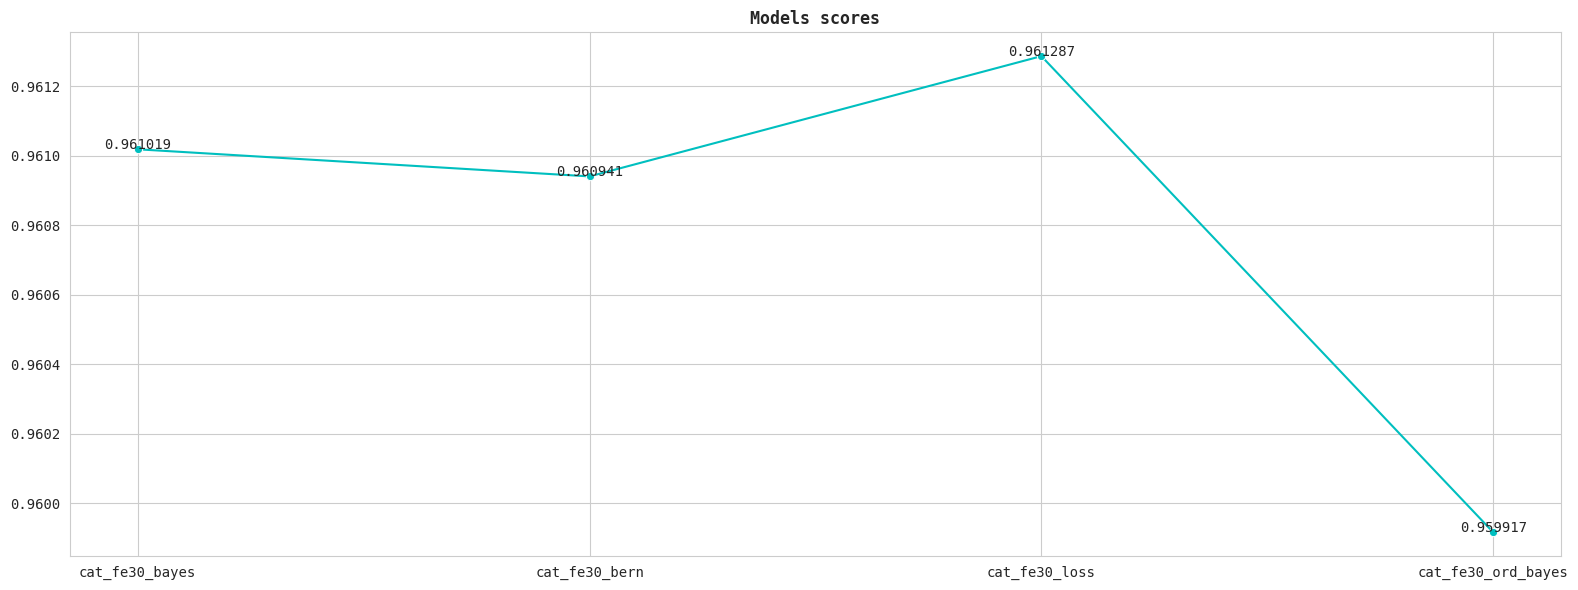

In [41]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("Models scores", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

plt.tight_layout()
plt.show()

cat_fe30_bayes_961019 saved!


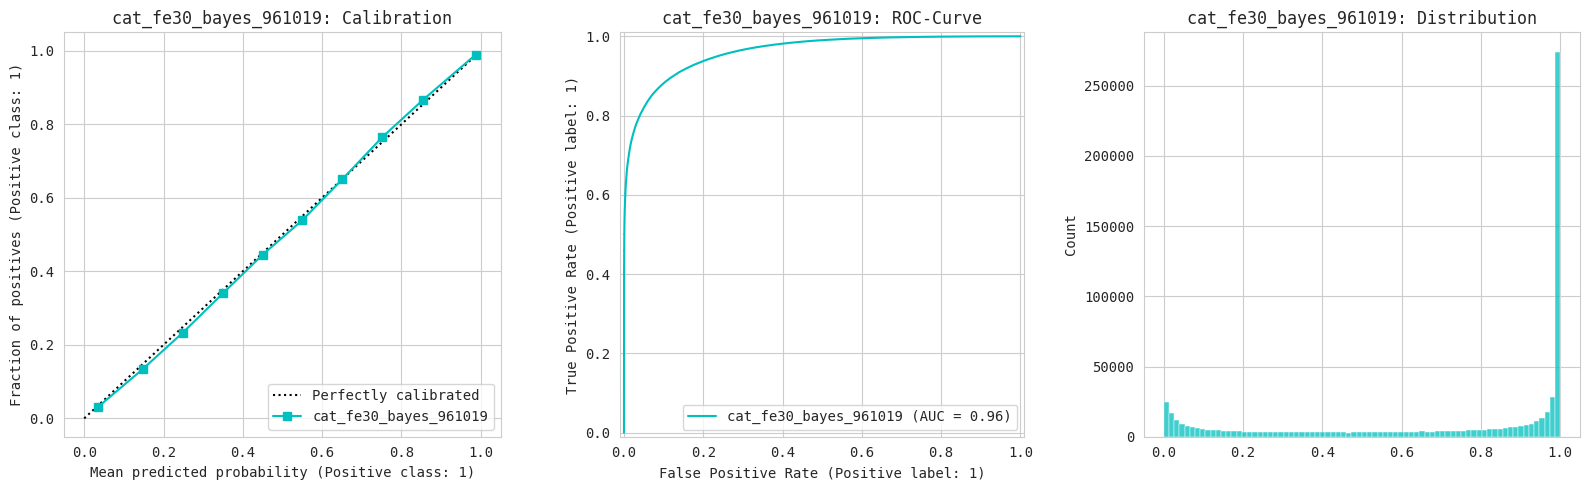


cat_fe30_bern_960941 saved!


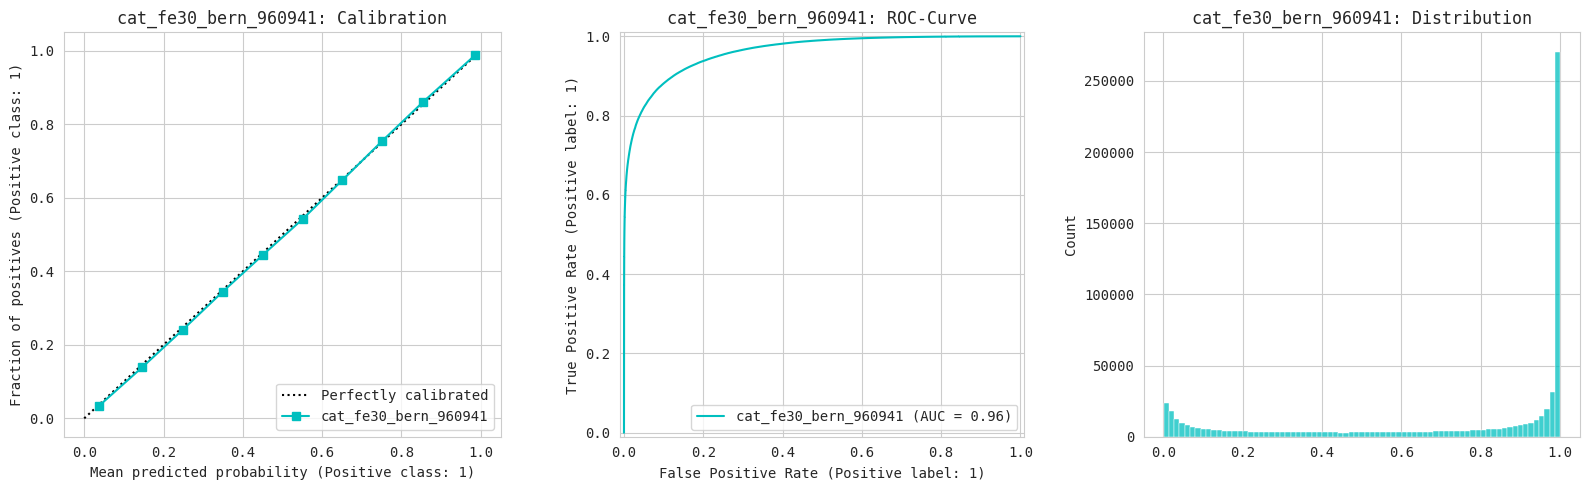


cat_fe30_loss_961287 saved!


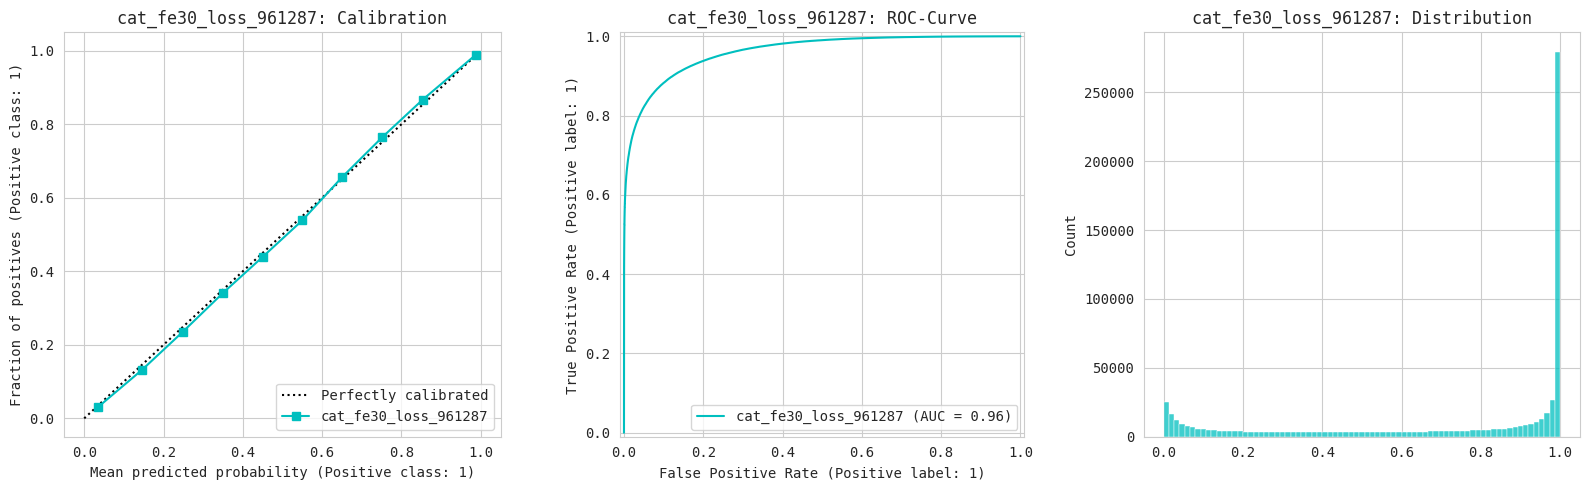


cat_fe30_ord_bayes_959917 saved!


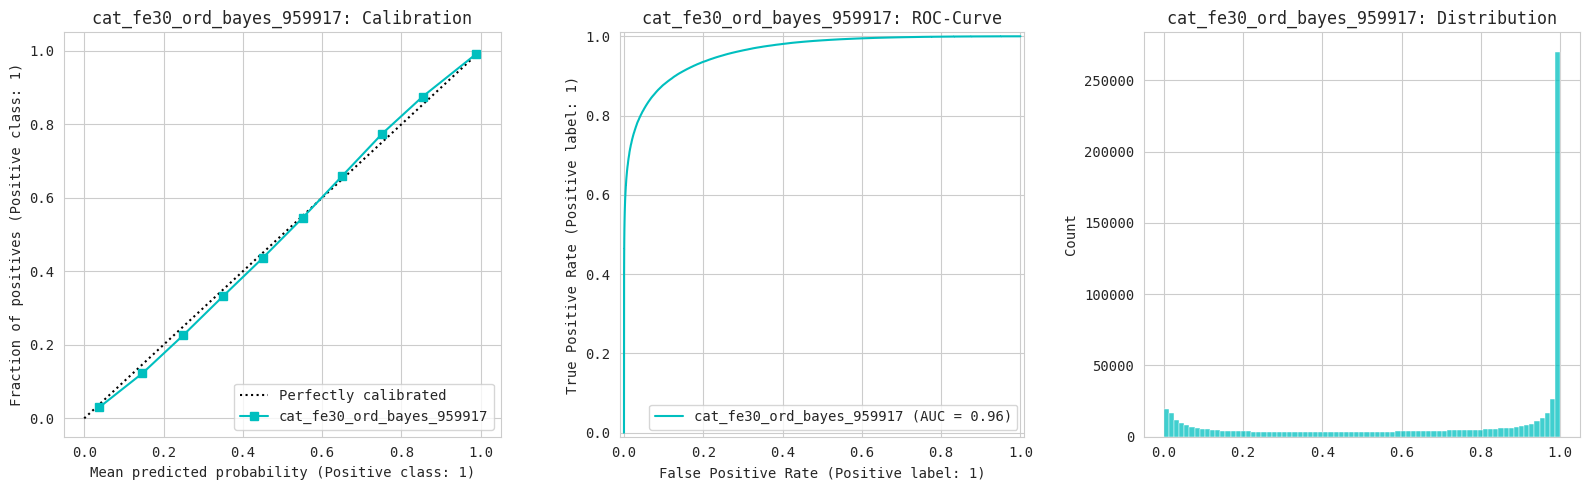

In [42]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [43]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

cat_fe30_bayes_961019 saved! (296302,)
cat_fe30_bern_960941 saved! (296302,)
cat_fe30_loss_961287 saved! (296302,)
cat_fe30_ord_bayes_959917 saved! (296302,)


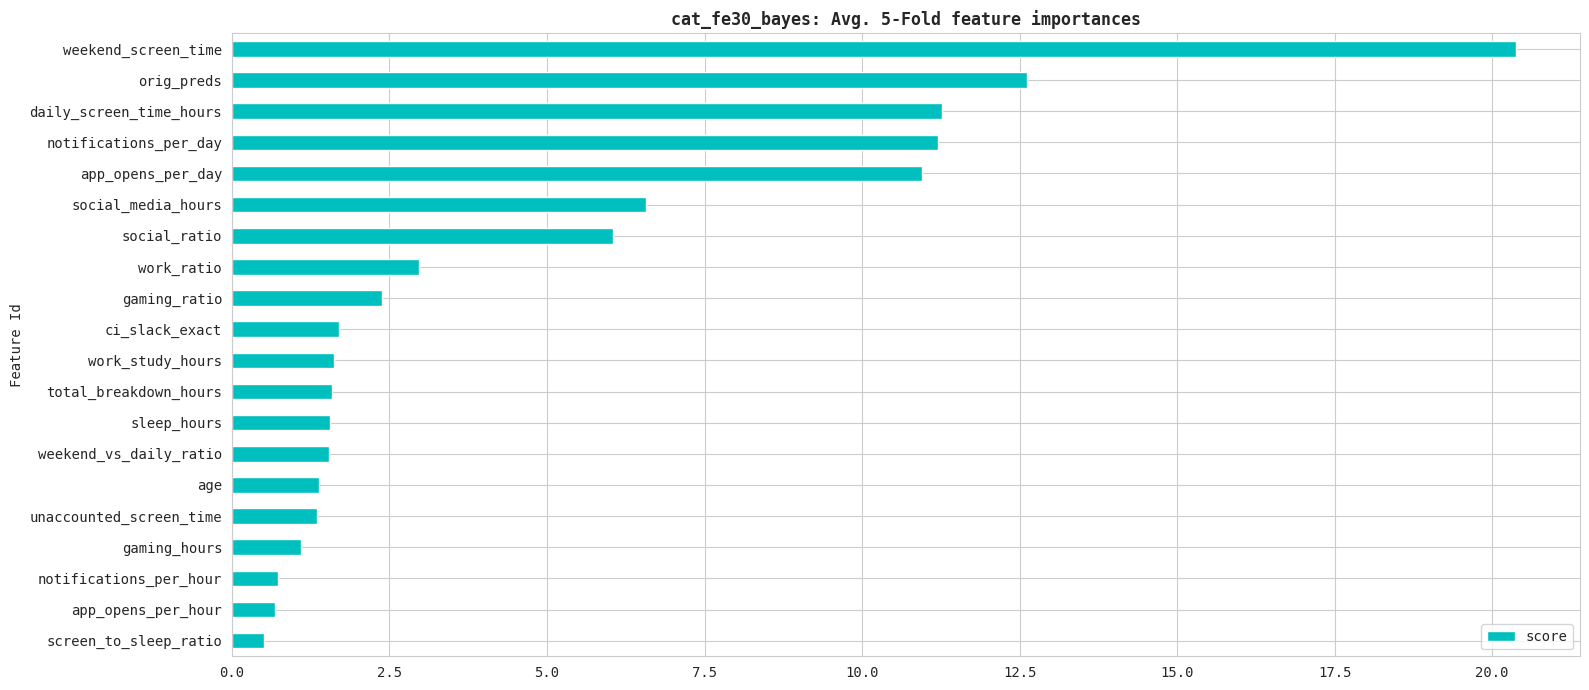

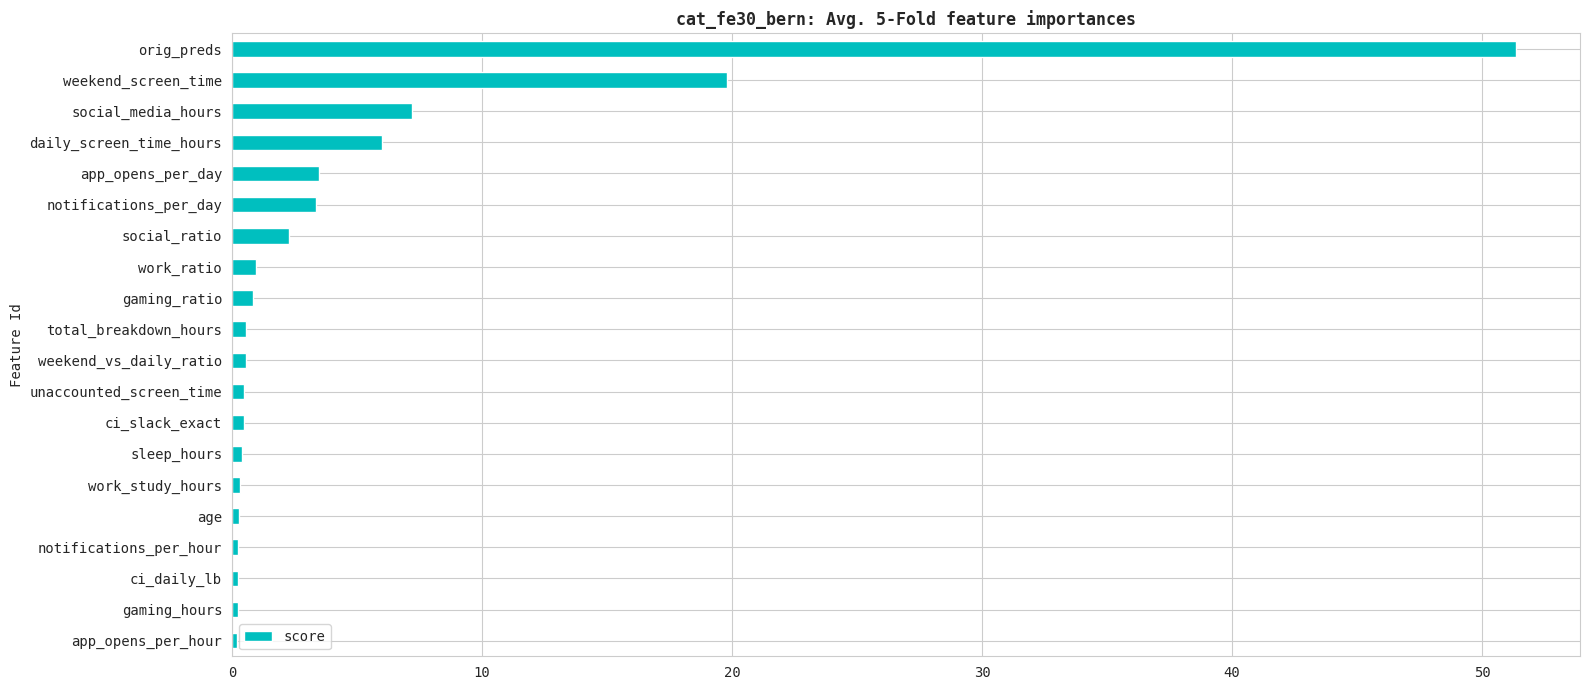

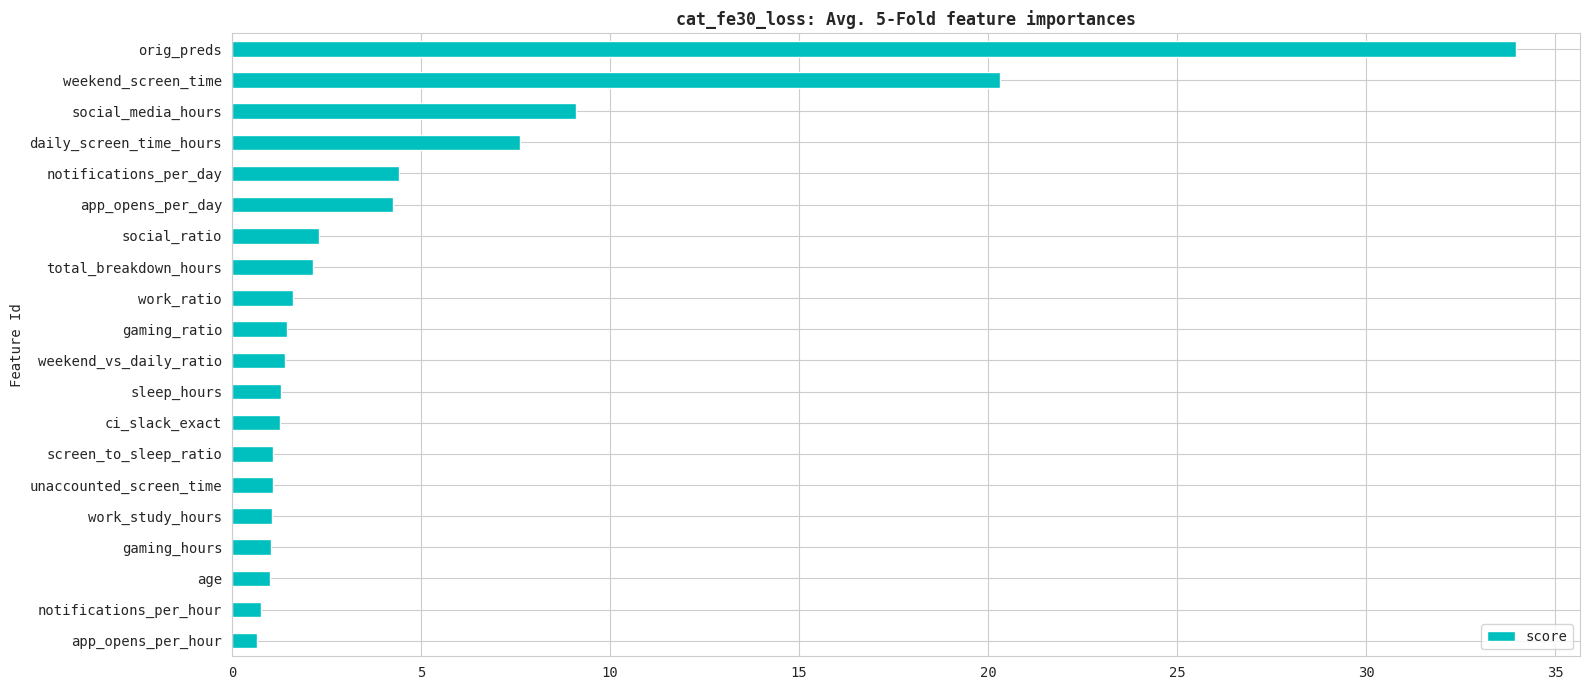

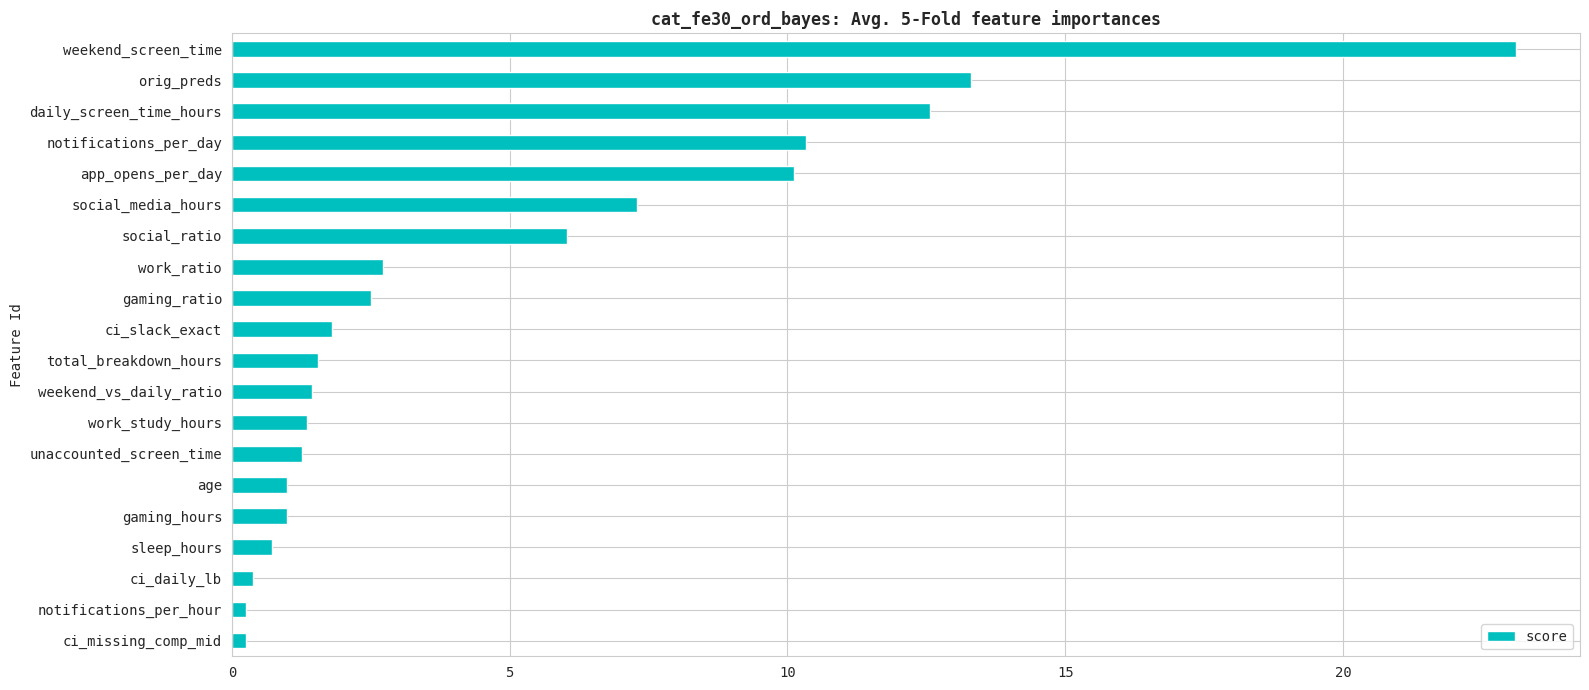

In [44]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_feat_importances[k] = y # np.mean(value, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_valid, [1] select y_valid

top_n = 20

for i, (m, df) in enumerate(all_feat_importances.items()):
    df_merge = df[0].merge(df[1], how="left", on="Feature Id", suffixes=("_0", ""))\
                    .merge(df[2], how="left", on="Feature Id", suffixes=("_1", ""))\
                    .merge(df[3], how="left", on="Feature Id", suffixes=("_2", ""))\
                    .merge(df[4], how="left", on="Feature Id", suffixes=("_3", "_4"))

    # display(df_merge.head())
    ## -------------------------------------------------------------------------------
    # df_merge["avg_score"] = df_merge.iloc[:, 1:].mean(axis=1)
    # df_merge.sort_values(by="avg_score").iloc[:, :top_n].plot.barh(y="avg_score", x="Feature Id", figsize=(18, 8))
    # plt.tight_layout()
    # plt.show()
    # print()
    ## -------------------------------------------------------------------------------
    df_final = pd.concat([df[0]["Feature Id"], df_merge.drop(columns=["Feature Id"])\
                                                       .mean(axis=1)], axis=1)\
                                                       .rename(columns={0: "score"})\
                                                       .sort_values(by="score")

    ax = df_final.tail(top_n).plot.barh(y="score", x="Feature Id", figsize=(16, 7))
    ax.set_title(f"{m}: Avg. {CFG['FOLDS']}-Fold feature importances", fontweight="semibold")
    plt.tight_layout()
    plt.show()
    print()

In [45]:
pd.DataFrame(model_results)

,cat_fe30_bayes_961019,cat_fe30_bern_960941,cat_fe30_loss_961287,cat_fe30_ord_bayes_959917
0,0.999470,0.999470,0.999593,0.999330
1,0.952325,0.963617,0.952249,0.942638
2,0.962548,0.956609,0.952708,0.968695
3,0.979161,0.975883,0.986880,0.978155
4,0.995836,0.993060,0.996688,0.995429
...,...,...,...,...
296297,0.999982,0.999972,1.000000,0.999997
296298,0.902138,0.890817,0.883058,0.893413
296299,0.154806,0.139882,0.144075,0.189738
296300,0.673691,0.673058,0.664611,0.562139


In [46]:
# !rm -r /kaggle/working